## Comparative analysis for the baseline fitting of denatured and folded protein

In this notebook we fit the unfolded baseline to completly unfolded curves based on a temperature window of a set size from the high end of temperatures for curves of 330nm and 350nm. We compare two baseline fitting formulas, quadratic and exponential, and compare them for their ability to generalize to the whole curve. 

The data comes from *Fricke et al.*<sup>1</sup> 


<sup>1</sup> Fricke, Celia, et al. "On the thermal and chemical stability of DNAJB6b and its globular domains." Biophysical Chemistry 320 (2025): 107401.*

This notebook is possible thanks to the publication of the data and associated code.
See https://data.dtu.dk/articles/code/Fitting_of_thermal_and_chemical_denaturation/27679716

### Using the demo DSF data for evaluation of the two formulas

In [1]:
from baseline_helpers import unfolded_comp_fig

### Using the DNAJB6b baseline and one curve without inflection points as comparison (highest denaturant concentration)

In [2]:
from dataclasses import dataclass
import pandas as pd
from pychemelt import Monomer
import numpy as np
@dataclass
class pantasample:
    T: np.ndarray
    f330: np.ndarray
    f350: np.ndarray
    denaturant: float

df = pd.read_csv('../data/nanoDSF_B6.csv', sep = '\t')

# Denaturant concentrations in M
denaturants = [0, 0.08, 0.4, 0.8, 1.2, 1.6, 2, 2.4, 2.8, 3.2, 3.6, 4, 4.4, 4.8, 5.2, 5.6, 6, 6.4]

B6 = [] # List for storing unfolding measurements
for i in range(18):

    temperature = df[df.columns[i*12]].values + 273.15  # Convert to Kelvin

    B6.append(pantasample(df[df.columns[i*12]].values, df[df.columns[i*12+9]].values, df[df.columns[i*12+5]].values, denaturants[i])) 

sample = Monomer()

signal_dic = {}
temp_dic = {}

# Create a signal matrix from each B6 f350 array
signal_matrix = np.array([b6.f350 for b6 in B6])  
temp_matrix = np.array([b6.T for b6 in B6]) 

assert (temp_matrix.shape == signal_matrix.shape)  # Should be True

sample.signal_dic['350nm'] = signal_matrix
sample.temp_dic['350nm'] = temp_matrix

# Create a signal matrix from each B6 f330 array
signal_matrix = np.array([b6.f330 for b6 in B6])  
temp_matrix = np.array([b6.T for b6 in B6]) 

assert (temp_matrix.shape == signal_matrix.shape)  # Should be True

sample.signal_dic['330nm'] = signal_matrix
sample.temp_dic['330nm'] = temp_matrix

conditions = [b6.denaturant for b6 in B6]
sample.conditions = conditions

sample.set_signal(['350nm','330nm'])

sample.set_denaturant_concentrations()
selected = [False] * 13 + [True] * 1 + [False] * 4
sample.select_conditions(selected,normalise_to_global_max=True)

print(sample.denaturant_concentrations)

[4.8]


### Using a dataset containing curves for the DNAJB6b dataset

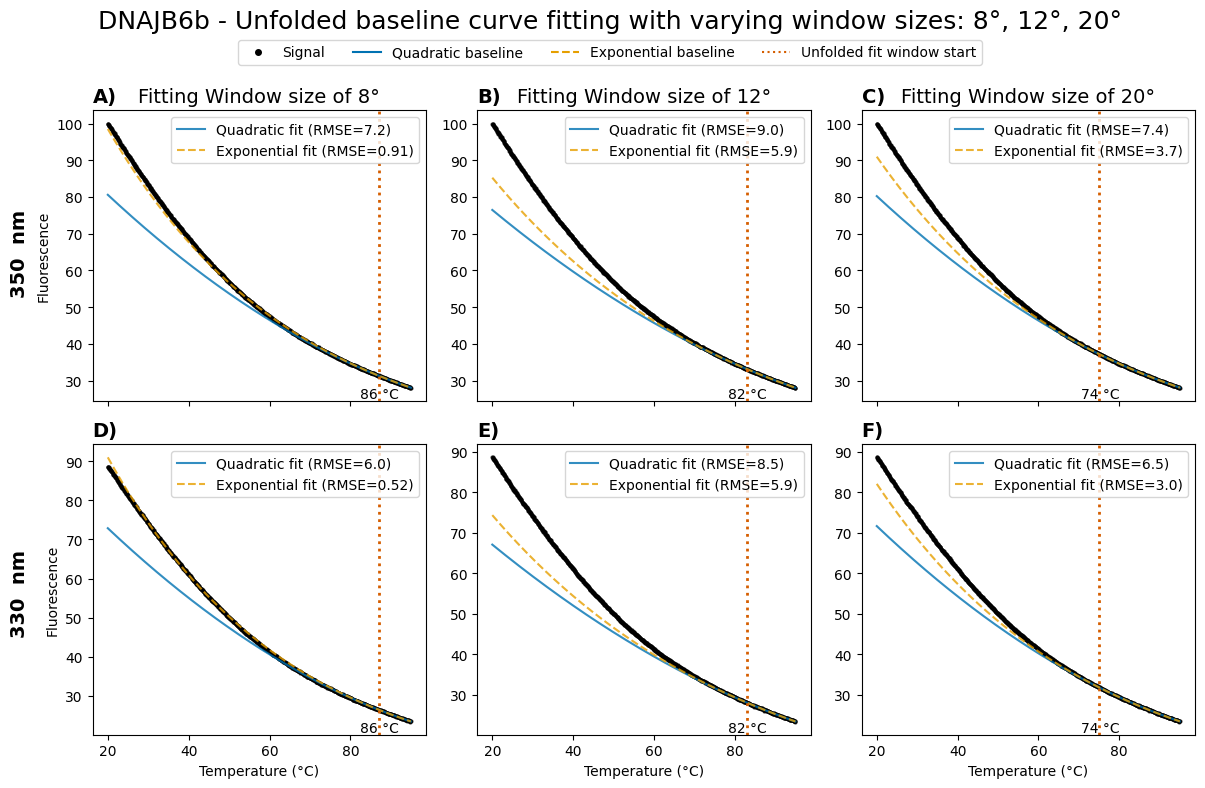

In [3]:
#using unfolded curves of the DNAJB6b dataset
conditions = [True] + [False] * 17
fig = unfolded_comp_fig(filename=sample,condition=conditions,windows=[8, 12, 20],signals=['350 nm','330 nm'],subtitle='DNAJB6b')

fig.savefig("./figs/1b_unfolded_baseline_analysis_DNAJB6b.png")